# Regressão Fracionária

In [1]:
import os
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> project root
os.chdir(ROOT)


In [2]:
import pandas as pd
import plotly.express as px
import kaleido
from pathlib import Path
import numpy as np

from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import Logit
import statsmodels.api as sm

import plotly.io as pio

pio.renderers.default = "png"

config_plotly = {"staticPlot": True}

pd.set_option("display.max_columns", None)

DATA_PATH = Path().resolve() / "data" / "processed"

rrd_df = pd.read_parquet(DATA_PATH / "rrd_df_novo.parquet")

# Total de recursos do partido por lista (denominador compartilhado)
rrd_df["vr_receita_total_partido"] = rrd_df.groupby(
    ["ano_eleicao", "sg_uf", "sg_partido"]
)["vr_receita_recursos_partidos"].transform("sum")

# Prop. condicional: NaN para quem não recebeu (usada no modelo intensiva_cond)
rrd_df["prop_vr_receita_candidato"] = (
    rrd_df["vr_receita_recursos_partidos"] / rrd_df["vr_receita_total_partido"]
)

# Margem extensiva: 1 = recebeu algo do partido
rrd_df["recebe_recursos"] = (
    rrd_df["vr_receita_recursos_partidos"].fillna(0) > 0
).astype(int)

# Prop. com zeros: não-receptores recebem 0 (usada no modelo intensiva_zeros)
rrd_df["prop_vr_receita_zeros"] = rrd_df["prop_vr_receita_candidato"].fillna(0)

# Diagnóstico
print(rrd_df.groupby(["ano_eleicao", "recebe_recursos"]).size().unstack().rename(
    columns={0: "recebe=0", 1: "recebe=1"}
))

recebe_recursos  recebe=0  recebe=1
ano_eleicao                        
2014                 3838      2340
2018                 2046      5584
2022                 1086      8589


In [3]:
formula_h1 = """ 
    prop_vr_receita_candidato ~ 
    n_eleicoes_prefeito + n_eleicoes_vereador 
    + n_eleicoes_deputado_estadual + n_eleicoes_deputado_federal 
    + n_eleicoes_governador + n_eleicoes_senador 
    + prop_votos_nominais_lag 
    + mulher + negra
    + C(sg_partido) + np.log(qt_vaga)
"""


def calcular_ame_baseline(rrd_df, ano: str):

    rrd_df = rrd_df.loc[rrd_df["ano_eleicao"] == int(ano)].copy()
    rrd_df = rrd_df.dropna(subset=["prop_vr_receita_candidato"])

    mod_h1 = sm.GLM.from_formula(
        formula_h1, data=rrd_df, family=Binomial(link=Logit()), missing="drop"
    )

    used_idx = mod_h1.data.row_labels
    groups = (
        rrd_df.loc[used_idx, "sg_partido"].astype(str)
        + "_"
        + rrd_df.loc[used_idx, "sg_uf"].astype(str)
    ).to_numpy()

    res_h1 = mod_h1.fit(cov_type="cluster", cov_kwds={"groups": groups})

    # AMEs baseline
    marg = res_h1.get_margeff(at="overall", method="dydx")
    df_ame_baseline = (
        marg.summary_frame()
        .reset_index()
        .rename(columns={"index": "variavel"})
        .round(4)
    )
    df_ame_baseline["ano"] = ano
    
    return res_h1, df_ame_baseline


res_h1_18, df_ame_baseline18 = calcular_ame_baseline(rrd_df, "2018")
res_h1_22, df_ame_baseline22 = calcular_ame_baseline(rrd_df, "2022")

df_output_partido = pd.concat([df_ame_baseline18, df_ame_baseline22], axis=0)
df_output_partido.to_parquet("data/processed/df_ame_baseline.parquet", index=False)

## Modelo de duas partes (hurdle)

Decomposição em **margem extensiva** — logit P(recebe > 0 | X), amostra completa — e **margem intensiva com zeros** — logit fracionário E(prop | X), amostra completa com `fillna(0)`. Contraste com o modelo intensivo condicional (restrito a Y > 0) já estimado acima.

| Modelo | VD | Amostra |
|--------|-----|---------|
| `intensiva_cond` | `prop_vr_receita_candidato` (NaN → excluído) | apenas receptores |
| `extensiva` | `recebe_recursos` ∈ {0, 1} | completa |
| `intensiva_zeros` | `prop_vr_receita_zeros` ∈ [0, 1] | completa |

In [4]:
formula_extensiva = """
    recebe_recursos ~
    n_eleicoes_prefeito + n_eleicoes_vereador
    + n_eleicoes_deputado_estadual + n_eleicoes_deputado_federal
    + n_eleicoes_governador + n_eleicoes_senador
    + prop_votos_nominais_lag
    + mulher + negra
    + C(sg_partido) + np.log(qt_vaga)
"""

formula_intensiva_zeros = """
    prop_vr_receita_zeros ~
    n_eleicoes_prefeito + n_eleicoes_vereador
    + n_eleicoes_deputado_estadual + n_eleicoes_deputado_federal
    + n_eleicoes_governador + n_eleicoes_senador
    + prop_votos_nominais_lag
    + mulher + negra
    + C(sg_partido) + np.log(qt_vaga)
"""


def _fit_glm_ame(formula, df, ano):
    df_ano = df.loc[df["ano_eleicao"] == int(ano)].copy()
    mod = sm.GLM.from_formula(
        formula, data=df_ano, family=Binomial(link=Logit()), missing="drop"
    )
    used_idx = mod.data.row_labels
    groups = (
        df_ano.loc[used_idx, "sg_partido"].astype(str)
        + "_" + df_ano.loc[used_idx, "sg_uf"].astype(str)
    ).to_numpy()
    res = mod.fit(cov_type="cluster", cov_kwds={"groups": groups})
    marg = res.get_margeff(at="overall", method="dydx")
    df_ame = (
        marg.summary_frame().reset_index()
        .rename(columns={"index": "variavel"})
        .round(4)
    )
    df_ame["ano"] = ano
    return res, df_ame


# Margem extensiva
res_ext_18, df_ame_ext_18 = _fit_glm_ame(formula_extensiva, rrd_df, "2018")
res_ext_22, df_ame_ext_22 = _fit_glm_ame(formula_extensiva, rrd_df, "2022")
df_ame_extensiva = pd.concat([
    df_ame_ext_18.assign(modelo="extensiva"),
    df_ame_ext_22.assign(modelo="extensiva"),
], axis=0)
df_ame_extensiva.to_parquet("data/processed/df_ame_extensiva.parquet", index=False)

# Margem intensiva com zeros (full sample)
res_iz_18, df_ame_iz_18 = _fit_glm_ame(formula_intensiva_zeros, rrd_df, "2018")
res_iz_22, df_ame_iz_22 = _fit_glm_ame(formula_intensiva_zeros, rrd_df, "2022")
df_ame_intensiva_zeros = pd.concat([
    df_ame_iz_18.assign(modelo="intensiva_zeros"),
    df_ame_iz_22.assign(modelo="intensiva_zeros"),
], axis=0)
df_ame_intensiva_zeros.to_parquet("data/processed/df_ame_intensiva_zeros.parquet", index=False)

# Tabela comparativa (sem dummies de partido)
_cols = ["variavel", "dy/dx", "Std. Err.", "Pr(>|z|)", "ano", "modelo"]
df_dois_estagios = pd.concat([
    df_ame_extensiva[_cols],
    df_output_partido.assign(modelo="intensiva_cond")[_cols],
    df_ame_intensiva_zeros[_cols],
], axis=0)
df_dois_estagios = df_dois_estagios[
    ~df_dois_estagios["variavel"].str.startswith("C")
].copy()
df_dois_estagios.to_parquet("data/processed/df_ame_dois_estagios.parquet", index=False)

# Cobertura amostral
print("N efetivo por modelo:")
for label, r18, r22 in [
    ("extensiva       ", res_ext_18, res_ext_22),
    ("intensiva_zeros ", res_iz_18,  res_iz_22),
    ("intensiva_cond  ", res_h1_18,  res_h1_22),
]:
    print(f"  {label}  2018={r18.nobs:.0f}  2022={r22.nobs:.0f}")

c:\Users\yuri.taba\AppData\Local\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:257: RuntimeWarning:

divide by zero encountered in divide

c:\Users\yuri.taba\AppData\Local\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:576: RuntimeWarning:

invalid value encountered in multiply

c:\Users\yuri.taba\AppData\Local\anaconda3\Lib\site-packages\statsmodels\genmod\families\links.py:257: RuntimeWarning:

divide by zero encountered in divide

c:\Users\yuri.taba\AppData\Local\anaconda3\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:576: RuntimeWarning:

invalid value encountered in multiply



N efetivo por modelo:
  extensiva         2018=7626  2022=9616
  intensiva_zeros   2018=7626  2022=9616
  intensiva_cond    2018=5581  2022=8535


C:\Users\yuri.taba\AppData\Local\Temp\ipykernel_9868\1177129794.py:40: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




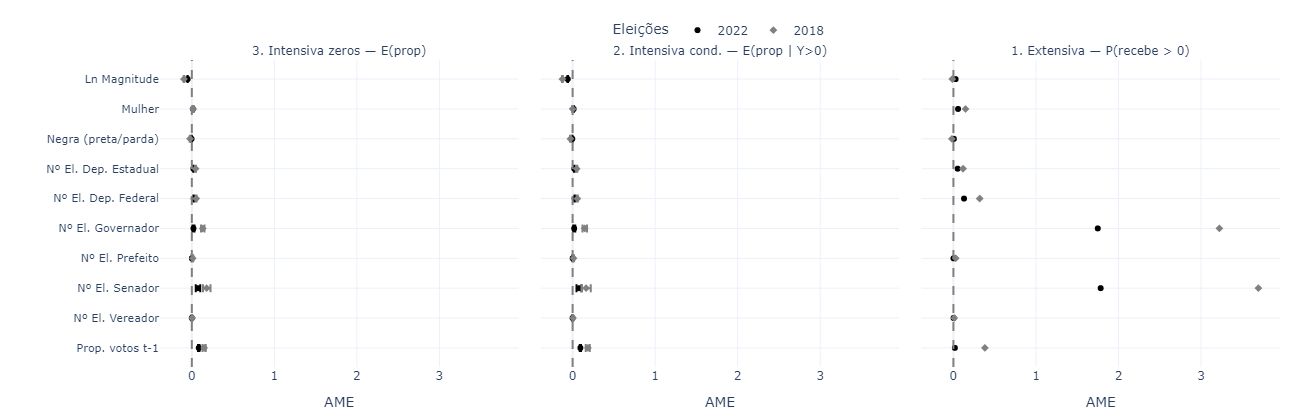

In [5]:
_labels = {
    "n_eleicoes_deputado_estadual": "Nº El. Dep. Estadual",
    "n_eleicoes_deputado_federal":  "Nº El. Dep. Federal",
    "n_eleicoes_senador":           "Nº El. Senador",
    "n_eleicoes_governador":        "Nº El. Governador",
    "n_eleicoes_vereador":          "Nº El. Vereador",
    "n_eleicoes_prefeito":          "Nº El. Prefeito",
    "np.log(qt_vaga)":              "Ln Magnitude",
    "prop_votos_nominais_lag":      "Prop. votos t-1",
    "mulher":                       "Mulher",
    "negra":                        "Negra (preta/parda)",
}
_facetas = {
    "extensiva":       "1. Extensiva — P(recebe > 0)",
    "intensiva_cond":  "2. Intensiva cond. — E(prop | Y>0)",
    "intensiva_zeros": "3. Intensiva zeros — E(prop)",
}

df_plot2 = df_dois_estagios[df_dois_estagios["variavel"].isin(_labels)].copy()
df_plot2["variavel_label"] = df_plot2["variavel"].map(_labels)
df_plot2["faceta"] = df_plot2["modelo"].map(_facetas)

fig2 = px.scatter(
    df_plot2.sort_values("variavel_label", ascending=False),
    y="variavel_label", x="dy/dx", error_x="Std. Err.",
    facet_col="faceta", color="ano", symbol="ano",
    color_discrete_sequence=["black", "grey"],
    template="plotly_white",
    width=1300, height=420,
    labels={"dy/dx": "AME", "variavel_label": ""},
)
fig2.add_vline(x=0, line_dash="dash", line_color="grey")
fig2.update_layout(
    font=dict(size=12),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5, title_text="Eleições"),
    margin=dict(l=160, r=20, t=60, b=40),
)
fig2.update_yaxes(tickfont=dict(size=11))
fig2.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig2.write_image("figs/cap4_ame_dois_estagios.png", scale=2)
fig2.show(config=config_plotly)

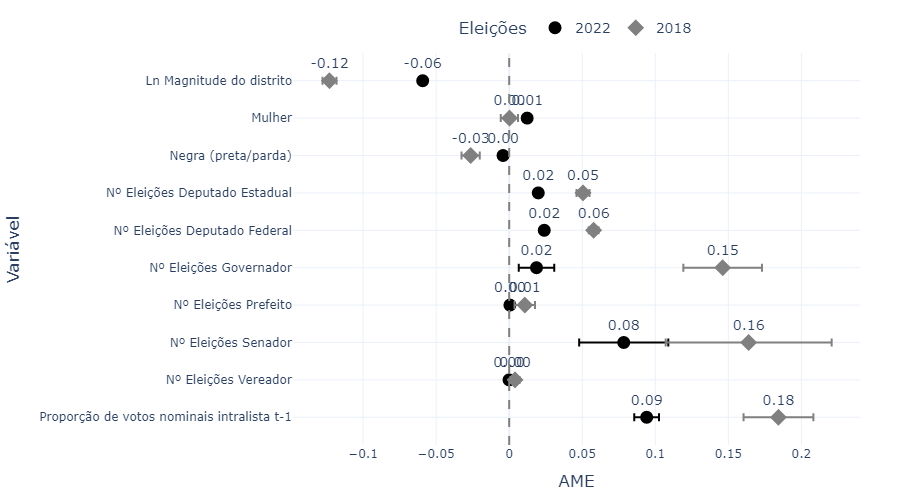

In [6]:
df_output_modelo = df_output_partido.copy()

df_output_modelo_print = df_output_modelo.loc[
    ~df_output_modelo["variavel"].str.startswith("C")
].copy()

df_output_modelo_print["variavel"] = (
    df_output_modelo_print["variavel"]
    .str.replace("n_eleicoes_deputado_estadual", "Nº Eleições Deputado Estadual")
    .str.replace("n_eleicoes_deputado_federal", "Nº Eleições Deputado Federal")
    .str.replace("n_eleicoes_senador", "Nº Eleições Senador")
    .str.replace("n_eleicoes_governador", "Nº Eleições Governador")
    .str.replace("n_eleicoes_vereador", "Nº Eleições Vereador")
    .str.replace("n_eleicoes_prefeito", "Nº Eleições Prefeito")
    .str.replace("np.log(qt_vaga)", "Ln Magnitude do distrito")
    .str.replace(
        "prop_votos_nominais_lag", "Proporção de votos nominais intralista t-1"
    )
    .str.replace("mulher", "Mulher")
    .str.replace("negra", "Negra (preta/parda)")
)


fig_modelo = px.scatter(
    df_output_modelo_print.sort_values("variavel", ascending=False),
    y="variavel",
    x="dy/dx",
    error_x="Std. Err.",
    labels={"dy/dx": "AME", "variavel": "Variável"},
    template="plotly_white",
    color="ano",
    width=800,
    symbol="ano",
    color_discrete_sequence=["black", "grey"],
    text="dy/dx",
)
fig_modelo.add_vline(x=0, line_dash="dash", line_color="grey")
fig_modelo.update_layout(
    legend=dict(
        orientation="h",        # horizontal
        yanchor="bottom",
        y=1.02,                # posição acima do plot; ajuste (p.ex. 1.08) para mais distância
        xanchor="center",
        x=0.5,
        title_text="Eleições"  # altera o título
    ),
    font=dict(size=14),
    margin=dict(l=140, r=40, t=40, b=40),
    width=900,
    height=500,
    autosize=False,
)
fig_modelo.update_yaxes(tickfont=dict(size=12))
fig_modelo.update_xaxes(tickfont=dict(size=12))
fig_modelo.update_traces(
    texttemplate="%{text:.2f}",
    textposition="top center",
    marker=dict(size=13),
)

## Efeitos por partido

In [7]:
def g_computation_contagens_por_partido(res, df_base, partido):
    """
    Calcula efeitos contrafactuais usando apenas n_eleicoes (sem dummies):
    - Efeito de ter sido eleito 1x vs nunca (0 → 1)
    - Efeito marginal de +1 eleição adicional (média para quem já tem experiência)
    - Efeito de experiência moderada vs alta (ex: 1 eleição → 3 eleições)
    """
    # Filtrar observações do partido
    mask = df_base.loc[res.model.data.row_labels, "sg_partido"] == partido
    df_partido = df_base.loc[res.model.data.row_labels][mask].copy()
    
    resultados = []

    # --- 1) Efeito de ter sido eleito 1x vs nunca (extensive margin)
    df_nunca = df_partido.copy()
    df_uma_vez = df_partido.copy()
    
    df_nunca["n_eleicoes_deputado_federal"] = 0
    df_uma_vez["n_eleicoes_deputado_federal"] = 1
    
    y_nunca = res.predict(df_nunca)
    y_uma_vez = res.predict(df_uma_vez)
    ame_extensive = (y_uma_vez - y_nunca).mean()
    
    resultados.append({
        "sg_partido": partido,
        "variavel": "deputado_federal_0to1",  # 0 → 1 eleição
        "ame": ame_extensive,
        "n_obs": len(df_partido),
        "interpretacao": "Efeito de ter sido eleito 1x vs nunca"
    })

    # --- 2) Efeito marginal de +1 eleição (intensive margin)
    # Calculado na média de todas as observações
    df_atual = df_partido.copy()
    df_mais1 = df_partido.copy()
    df_mais1["n_eleicoes_deputado_federal"] += 1
    
    y_atual = res.predict(df_atual)
    y_mais1 = res.predict(df_mais1)
    ame_intensive = (y_mais1 - y_atual).mean()
    
    resultados.append({
        "sg_partido": partido,
        "variavel": "deputado_federal_plus1",  # +1 eleição
        "ame": ame_intensive,
        "n_obs": len(df_partido),
        "interpretacao": "Efeito marginal de +1 eleição adicional"
    })

    return pd.DataFrame(resultados)


def aplicar_gcomputation_contagens(modelo, rrd_df, ano):
    """
    Aplica G-computation para modelo sem dummies
    """
    df_usado = rrd_df.loc[modelo.model.data.row_labels].copy()
    partidos = sorted(
        df_usado["sg_partido"].value_counts()[lambda s: s >= 30].index
    )

    lista_res = []
    for p in partidos:
        res_part = g_computation_contagens_por_partido(modelo, df_usado, p)
        if res_part is not None:
            lista_res.append(res_part)

    df_gcomp = pd.concat(lista_res, ignore_index=True)
    df_gcomp['ano'] = ano

    return df_gcomp


# Aplicar para ambos os anos
modelo_contagens_18 = aplicar_gcomputation_contagens(res_h1_18, rrd_df, "2018")
modelo_contagens_22 = aplicar_gcomputation_contagens(res_h1_22, rrd_df, "2022")

modelo_contagens = pd.concat([modelo_contagens_18, modelo_contagens_22], axis=0)

# Salvar
modelo_contagens.to_parquet("data/processed/df_gcomp_contagens_modelo_tese.parquet")

## Robustez 2 — Efeitos correlacionados aleatórios (Wooldridge 2010)

**Lógica:** heterogeneidade não-observada ao nível da lista (cultura organizacional do partido estadual, capacidade de coordenação, histórico de alocação) pode confundir H1. O Mundlak device inclui as médias intra-grupo das variáveis de credencial como controles adicionais — o coeficiente das variáveis originais passa a ser o efeito *within*, purificado da heterogeneidade entre listas.

Grupo = `sg_partido × sg_uf` (uma lista eleitoral). Se os coeficientes das credenciais permanecerem significativos e positivos após o controle pelas médias do grupo, o resultado de H1 não é artefato de heterogeneidade organizacional não-observada.

In [8]:
_within_vars = [
    "n_eleicoes_prefeito", "n_eleicoes_vereador",
    "n_eleicoes_deputado_estadual", "n_eleicoes_deputado_federal",
    "n_eleicoes_governador", "n_eleicoes_senador",
    "prop_votos_nominais_lag",
]


def calcular_cre(df_full, ano):
    df = df_full.loc[df_full["ano_eleicao"] == int(ano)].copy()
    ycol = "prop_vr_receita_candidato"

    df["grupo"] = df["sg_partido"].astype(str) + "_" + df["sg_uf"].astype(str)

    # Médias intra-lista (Mundlak device)
    means = (
        df.groupby("grupo", observed=True)[_within_vars]
        .mean().add_prefix("mean_").reset_index()
    )
    df = df.merge(means, on="grupo", how="left")

    # Restringir a receptores (mesmo universo do modelo baseline intensiva_cond)
    df = df.dropna(subset=[ycol] + _within_vars + ["mulher", "negra", "qt_vaga"])

    within_str  = " + ".join(_within_vars)
    between_str = " + ".join([f"mean_{v}" for v in _within_vars])

    formula_cre = f"""
        {ycol} ~
        {within_str}
        + {between_str}
        + mulher + negra
        + np.log(qt_vaga)
        + C(sg_partido)
    """

    mod = sm.GLM.from_formula(
        formula_cre, data=df, family=Binomial(link=Logit()), missing="drop"
    )
    used_idx = mod.data.row_labels
    groups = df.loc[used_idx, "grupo"].to_numpy()
    res = mod.fit(cov_type="cluster", cov_kwds={"groups": groups})

    marg = res.get_margeff(at="overall", method="dydx")
    df_ame = (
        marg.summary_frame().reset_index()
        .rename(columns={"index": "variavel"})
        .round(4)
    )
    # Manter credenciais within + controles — excluir médias e dummies de partido
    keep = _within_vars + ["mulher", "negra", "np.log(qt_vaga)"]
    df_ame = df_ame[df_ame["variavel"].isin(keep)].copy()
    df_ame["ano"] = str(ano)
    df_ame["modelo"] = "cre"
    return res, df_ame


res_cre_18, df_ame_cre_18 = calcular_cre(rrd_df, 2018)
res_cre_22, df_ame_cre_22 = calcular_cre(rrd_df, 2022)

df_ame_cre = pd.concat([df_ame_cre_18, df_ame_cre_22], axis=0)
df_ame_cre.to_parquet("data/processed/df_ame_cre.parquet", index=False)

print(f"N CRE:      2018={res_cre_18.nobs:.0f}  2022={res_cre_22.nobs:.0f}")
print(f"N baseline: 2018={res_h1_18.nobs:.0f}  2022={res_h1_22.nobs:.0f}")

N CRE:      2018=5581  2022=8535
N baseline: 2018=5581  2022=8535


C:\Users\yuri.taba\AppData\Local\Temp\ipykernel_9868\1846352714.py:45: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




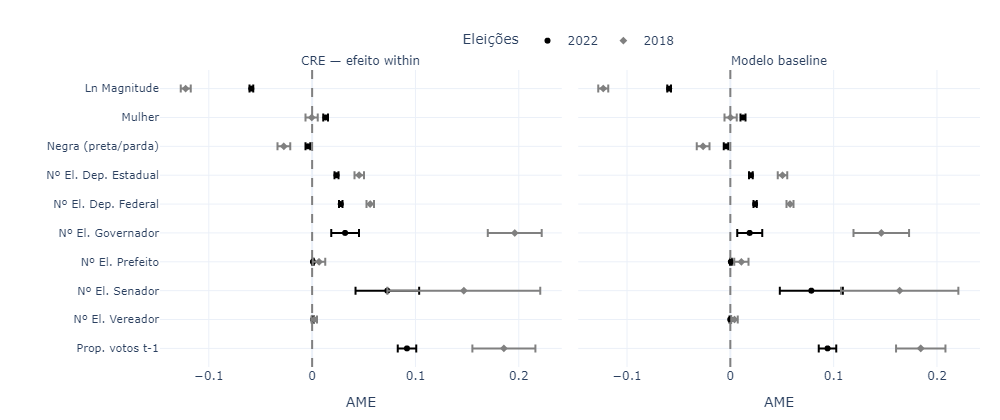

In [9]:
# --- Figura: baseline vs. CRE (efeito within) ---
_cre_labels = {
    "n_eleicoes_deputado_estadual": "Nº El. Dep. Estadual",
    "n_eleicoes_deputado_federal":  "Nº El. Dep. Federal",
    "n_eleicoes_senador":           "Nº El. Senador",
    "n_eleicoes_governador":        "Nº El. Governador",
    "n_eleicoes_vereador":          "Nº El. Vereador",
    "n_eleicoes_prefeito":          "Nº El. Prefeito",
    "np.log(qt_vaga)":              "Ln Magnitude",
    "prop_votos_nominais_lag":      "Prop. votos t-1",
    "mulher":                       "Mulher",
    "negra":                        "Negra (preta/parda)",
}
_cre_facetas = {
    "baseline": "Modelo baseline",
    "cre":      "CRE — efeito within",
}

_cols = ["variavel", "dy/dx", "Std. Err.", "Pr(>|z|)", "ano", "modelo"]
df_cre_compare = pd.concat([
    df_output_partido.assign(modelo="baseline")[_cols],
    df_ame_cre[_cols],
], axis=0)
df_cre_compare = df_cre_compare[df_cre_compare["variavel"].isin(_cre_labels)].copy()
df_cre_compare["variavel_label"] = df_cre_compare["variavel"].map(_cre_labels)
df_cre_compare["faceta"] = df_cre_compare["modelo"].map(_cre_facetas)

fig_cre = px.scatter(
    df_cre_compare.sort_values("variavel_label", ascending=False),
    y="variavel_label", x="dy/dx", error_x="Std. Err.",
    facet_col="faceta", color="ano", symbol="ano",
    color_discrete_sequence=["black", "grey"],
    template="plotly_white",
    width=1000, height=420,
    labels={"dy/dx": "AME", "variavel_label": ""},
)
fig_cre.add_vline(x=0, line_dash="dash", line_color="grey")
fig_cre.update_layout(
    font=dict(size=12),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5, title_text="Eleições"),
    margin=dict(l=160, r=20, t=70, b=40),
)
fig_cre.update_yaxes(tickfont=dict(size=11))
fig_cre.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig_cre.write_image("figs/cap4_cre_vs_baseline.png", scale=2)
fig_cre.show(config=config_plotly)

In [10]:
# rrd_df.groupby("ano_eleicao").agg({"vr_receita_total": "sum"}) / 1_000_000

In [11]:
(3241.58 - 1756.9) / 3241.58

0.4580112167523244

In [12]:
rrd_df.query("eleito == 1").groupby("ano_eleicao")['prop_vr_receita_candidato'].describe()

,count,mean,std,min,25%,50%,75%,max
ano_eleicao,,,,,,,,
2014,414.0,0.444640,0.379049,0.000513,0.090054,0.309501,0.873160,1.000000
2018,481.0,0.400679,0.333736,0.000084,0.128210,0.302470,0.664452,1.000000
2022,505.0,0.175174,0.153557,0.000163,0.075672,0.133401,0.224593,0.973854


## Robustez 1 — Placebo: receitas próprias

**Lógica:** se o resultado é captura (candidatos poderosos puxam recursos por influência), as credenciais eleitorais deveriam prever igualmente bem a arrecadação própria (`vr_receita_outros`) e os repasses partidários. Se o partido exerce discricionariedade deliberada, as credenciais devem prever **mais fortemente** os repasses do que a arrecadação própria.

VD placebo: `prop_vr_outros_candidato` = share de arrecadação própria do candidato dentro da lista (partido × UF × ano), com zeros para quem não arrecadou nada. Listas sem nenhuma arrecadação própria recebem NaN e são excluídas. Modelo idêntico ao principal (`intensiva_zeros`).

In [13]:
# --- VD placebo: share de arrecadação própria (condicional, clipped) ---
# Candidatos com vr_receita_outros > 0 apenas.
# Clip em [1e-4, 1-1e-4]: valores exatos de 0/1 tornam logit(y) = ±∞ (Papke & Wooldridge 1996).
# C(sg_uf) no lugar de C(sg_partido): coluna é estável (27 níveis) e adequada para
# controlar variação geográfica em arrecadação própria (partido não controla esse recurso).
# np.log(qt_vaga) OMITIDO: dentro de cada ano, qt_vaga é função determinística de sg_uf,
# portanto perfeitamente colinear com C(sg_uf). A magnitude distrital já está absorvida pelo FE.
rrd_df["vr_outros_total_lista"] = rrd_df.groupby(
    ["ano_eleicao", "sg_uf", "sg_partido"]
)["vr_receita_outros"].transform(lambda x: x.fillna(0).sum())

_eps = 1e-4
rrd_df["prop_vr_outros_cond"] = np.where(
    rrd_df["vr_receita_outros"].fillna(0) > 0,
    (rrd_df["vr_receita_outros"].fillna(0) / rrd_df["vr_outros_total_lista"]).clip(_eps, 1 - _eps),
    np.nan
)

formula_placebo = """
    prop_vr_outros_cond ~
    n_eleicoes_prefeito + n_eleicoes_vereador
    + n_eleicoes_deputado_estadual + n_eleicoes_deputado_federal
    + n_eleicoes_governador + n_eleicoes_senador
    + prop_votos_nominais_lag
    + mulher + negra
    + C(sg_uf)
"""

res_placebo_18, df_ame_placebo_18 = _fit_glm_ame(formula_placebo, rrd_df, "2018")
res_placebo_22, df_ame_placebo_22 = _fit_glm_ame(formula_placebo, rrd_df, "2022")

df_ame_placebo = pd.concat([
    df_ame_placebo_18.assign(modelo="placebo_outros"),
    df_ame_placebo_22.assign(modelo="placebo_outros"),
], axis=0)
df_ame_placebo.to_parquet("data/processed/df_ame_placebo_outros.parquet", index=False)

print(f"N placebo:    2018={res_placebo_18.nobs:.0f}  2022={res_placebo_22.nobs:.0f}")
print(f"N principal:  2018={res_h1_18.nobs:.0f}  2022={res_h1_22.nobs:.0f}")

N placebo:    2018=5677  2022=5671
N principal:  2018=5581  2022=8535


C:\Users\yuri.taba\AppData\Local\Temp\ipykernel_9868\2130112513.py:48: DeprecationWarning:


Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).




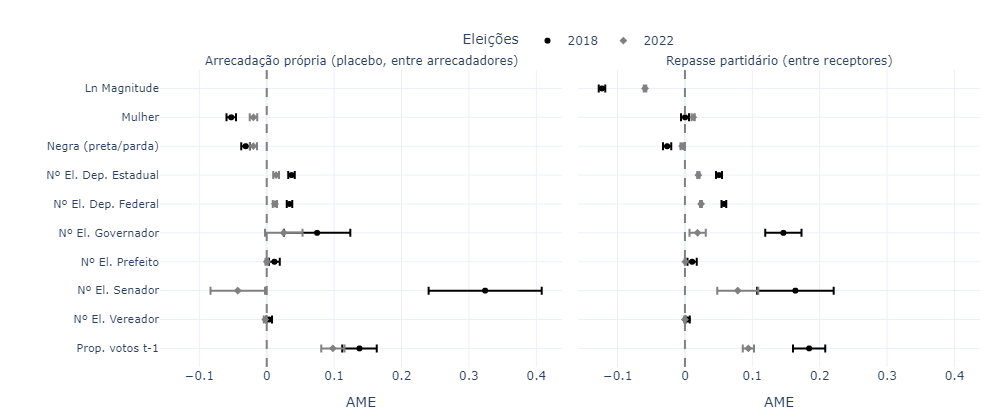

In [14]:
# --- Figura comparativa: repasse partidário (cond.) vs. arrecadação própria (cond.) ---
# Ambos os modelos usam a margem intensiva condicional para comparação limpa.
_labels_rob = {
    "n_eleicoes_deputado_estadual": "Nº El. Dep. Estadual",
    "n_eleicoes_deputado_federal":  "Nº El. Dep. Federal",
    "n_eleicoes_senador":           "Nº El. Senador",
    "n_eleicoes_governador":        "Nº El. Governador",
    "n_eleicoes_vereador":          "Nº El. Vereador",
    "n_eleicoes_prefeito":          "Nº El. Prefeito",
    "np.log(qt_vaga)":              "Ln Magnitude",
    "prop_votos_nominais_lag":      "Prop. votos t-1",
    "mulher":                       "Mulher",
    "negra":                        "Negra (preta/parda)",
}
_facetas_rob = {
    "intensiva_cond": "Repasse partidário (entre receptores)",
    "placebo_outros":  "Arrecadação própria (placebo, entre arrecadadores)",
}

_cols = ["variavel", "dy/dx", "Std. Err.", "Pr(>|z|)", "ano", "modelo"]
df_placebo_compare = pd.concat([
    df_output_partido.assign(modelo="intensiva_cond")[_cols],
    df_ame_placebo[_cols],
], axis=0)
df_placebo_compare = df_placebo_compare[
    df_placebo_compare["variavel"].isin(_labels_rob)
].copy()
df_placebo_compare["variavel_label"] = df_placebo_compare["variavel"].map(_labels_rob)
df_placebo_compare["faceta"] = df_placebo_compare["modelo"].map(_facetas_rob)

fig_placebo = px.scatter(
    df_placebo_compare.sort_values("variavel_label", ascending=False),
    y="variavel_label", x="dy/dx", error_x="Std. Err.",
    facet_col="faceta", color="ano", symbol="ano",
    color_discrete_sequence=["black", "grey"],
    template="plotly_white",
    width=1000, height=420,
    labels={"dy/dx": "AME", "variavel_label": ""},
)
fig_placebo.add_vline(x=0, line_dash="dash", line_color="grey")
fig_placebo.update_layout(
    font=dict(size=12),
    legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5, title_text="Eleições"),
    margin=dict(l=160, r=20, t=70, b=40),
)
fig_placebo.update_yaxes(tickfont=dict(size=11))
fig_placebo.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig_placebo.write_image("figs/cap4_placebo_receitas_proprias.png", scale=2)
fig_placebo.show(config=config_plotly)